In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D, Add
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
import emoji

In [87]:
!pip install emoji

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for emoji from https://files.pythonhosted.org/packages/91/db/a0335710caaa6d0aebdaa65ad4df789c15d89b7babd9a30277838a7d9aac/emoji-2.14.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/590.6 kB ? eta -:--:--
   -- ------------------------------------- 30.7/590.6 kB 1.3 MB/s eta 0:00:01
   --------------------------------------- 590.6/590.6 kB 12.3 MB/s eta 0:00:00


# Importing the dataset

In [2]:
x_train = pd.read_csv('X_train_2.csv')
x_test = pd.read_csv('X_test_2.csv')
x_val = pd.read_csv('X_val_2.csv')

y_train = pd.read_csv('y_train_2.csv')
y_test = pd.read_csv('y_test_2.csv')
y_val = pd.read_csv('y_val_2.csv')

In [50]:
x_test.shape

(88213, 6)

#  Creating seperate column for emojis

In [3]:
def contains_emoji(text):
    return any(char in emoji.EMOJI_DATA for char in text)

# Add `has_emoji` column to your dataset (e.g., x_train, x_test, etc.)
x_train['has_emoji'] = x_train['Tweet'].apply(contains_emoji)
x_test['has_emoji'] = x_test['Tweet'].apply(contains_emoji)
x_val['has_emoji'] = x_val['Tweet'].apply(contains_emoji)

#   Convering labels in numbers

In [4]:

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)


C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [5]:
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(x_train['clean_tweet'])

max_len = 64  

train_seq = tokenizer.texts_to_sequences(x_train['clean_tweet'])
val_seq = tokenizer.texts_to_sequences(x_val['clean_tweet'])
test_seq = tokenizer.texts_to_sequences(x_test['clean_tweet'])

train_pad = pad_sequences(train_seq, maxlen=max_len, padding='post')
val_pad = pad_sequences(val_seq, maxlen=max_len, padding='post')
test_pad = pad_sequences(test_seq, maxlen=max_len, padding='post')

In [6]:
train_meta = x_train[['tweet_length', 'num_hashtags', 'lexicon_score']].to_numpy()
val_meta = x_val[['tweet_length', 'num_hashtags', 'lexicon_score']].to_numpy()
test_meta = x_test[['tweet_length', 'num_hashtags', 'lexicon_score']].to_numpy()


#  Transformer model

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(vocab_size=10000, max_len=64, meta_input_dim=3, num_classes=3):
    text_input = layers.Input(shape=(max_len,), name='text_input')
    embed = layers.Embedding(input_dim=vocab_size, output_dim=64)(text_input)

    # Positional Encoding
    position_indices = tf.range(start=0, limit=max_len, delta=1)
    position_embedding = layers.Embedding(input_dim=max_len, output_dim=64)(position_indices)
    embed_with_pos = embed + position_embedding

    # Transformer Block
    transformer = layers.MultiHeadAttention(num_heads=2, key_dim=64)(embed_with_pos, embed_with_pos)
    x = layers.LayerNormalization()(transformer + embed_with_pos)
    x = layers.GlobalAveragePooling1D()(x)

    # Metadata Input
    meta_input = layers.Input(shape=(meta_input_dim,), name='meta_input')
    meta_dense = layers.Dense(16, activation='relu')(meta_input)

    # Concatenate text + meta
    concat = layers.concatenate([x, meta_dense])
    dense = layers.Dense(64, activation='relu')(concat)
    output = layers.Dense(num_classes, activation='softmax')(dense)

    model = models.Model(inputs=[text_input, meta_input], outputs=output)
    return model


In [8]:
model = build_model()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    [train_pad, train_meta],
    y_train_enc,
    validation_data=([val_pad, val_meta], y_val_enc),
    epochs=5,
    batch_size=32
)





Epoch 1/5


8270/8270 [==============================] - 165s 19ms/step - loss: 0.4533 - accuracy: 0.8377 - val_loss: 0.3775 - val_accuracy: 0.8589
Epoch 2/5
8270/8270 [==============================] - 163s 20ms/step - loss: 0.3418 - accuracy: 0.8750 - val_loss: 0.3426 - val_accuracy: 0.8751
Epoch 3/5
8270/8270 [==============================] - 160s 19ms/step - loss: 0.3125 - accuracy: 0.8858 - val_loss: 0.3375 - val_accuracy: 0.8795
Epoch 4/5
8270/8270 [==============================] - 161s 19ms/step - loss: 0.2929 - accuracy: 0.8935 - val_loss: 0.3394 - val_accuracy: 0.8803
Epoch 5/5
8270/8270 [==============================] - 162s 20ms/step - loss: 0.2779 - accuracy: 0.8987 - val_loss: 0.3324 - val_accuracy: 0.8797


#   test accuracy

In [9]:
test_loss, test_acc = model.evaluate([test_pad, test_meta], y_test_enc)
print(f"Test Accuracy: {test_acc:.4f}")


2757/2757 [==============================] - 22s 8ms/step - loss: 0.3344 - accuracy: 0.8797
Test Accuracy: 0.8797


In [10]:
train_preds_probs = model.predict([train_pad, train_meta])
test_preds_probs = model.predict([test_pad, test_meta])

# Convert to predicted class labels
train_preds = np.argmax(train_preds_probs, axis=1)
test_preds = np.argmax(test_preds_probs, axis=1)


2757/2757 [==============================] - 16s 6ms/step


# Classification report 

In [11]:
print("TRAINING CLASSIFICATION REPORT")
print(classification_report(y_train_enc, train_preds, target_names=label_encoder.classes_))

print('---------------------------------------------------------')

print("TEST CLASSIFICATION REPORT")
print(classification_report(y_test_enc, test_preds, target_names=label_encoder.classes_))

TRAINING CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.86      0.83      0.85     45941
     neutral       0.89      0.70      0.78     40221
    positive       0.92      0.98      0.95    178474

    accuracy                           0.91    264636
   macro avg       0.89      0.84      0.86    264636
weighted avg       0.91      0.91      0.91    264636

---------------------------------------------------------
TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

    negative       0.81      0.77      0.79     15314
     neutral       0.81      0.63      0.71     13407
    positive       0.91      0.96      0.93     59492

    accuracy                           0.88     88213
   macro avg       0.84      0.79      0.81     88213
weighted avg       0.88      0.88      0.88     88213



#  Confusion matrix

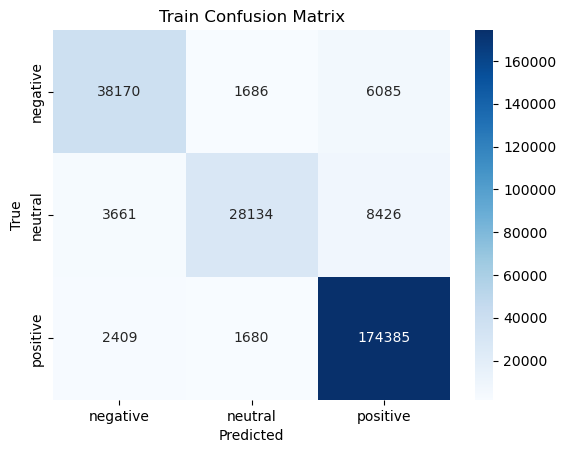

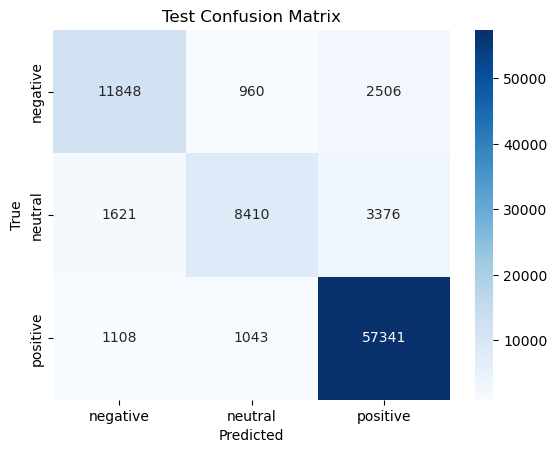

In [12]:
def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_train_enc, train_preds, title="Train Confusion Matrix")
plot_confusion_matrix(y_test_enc, test_preds, title="Test Confusion Matrix")


#  AUC - ROC accuracy

In [13]:
from sklearn.preprocessing import label_binarize

# Binarize labels for ROC AUC
y_train_bin = label_binarize(y_train_enc, classes=[0,1,2])
y_test_bin = label_binarize(y_test_enc, classes=[0,1,2])

# Compute macro AUC
train_auc = roc_auc_score(y_train_bin, train_preds_probs, average='macro', multi_class='ovr')
test_auc = roc_auc_score(y_test_bin, test_preds_probs, average='macro', multi_class='ovr')

print(f"Train ROC AUC Score: {train_auc:.4f}")
print(f"Test ROC AUC Score: {test_auc:.4f}")


Train ROC AUC Score: 0.9736
Test ROC AUC Score: 0.9522


In [14]:
from sklearn.preprocessing import label_binarize

# Classes: [Negative, Neutral, Positive] → adjust if different
n_classes = 3
y_train_bin = label_binarize(y_train_enc, classes=[0, 1, 2])
y_test_bin = label_binarize(y_test_enc, classes=[0, 1, 2])


In [15]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def plot_multiclass_roc(y_true_bin, y_pred_probs, dataset_name="Train"):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(8, 6))
    colors = ['blue', 'green', 'red']
    class_names = label_encoder.classes_

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"Class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{dataset_name} ROC Curve (One-vs-Rest)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


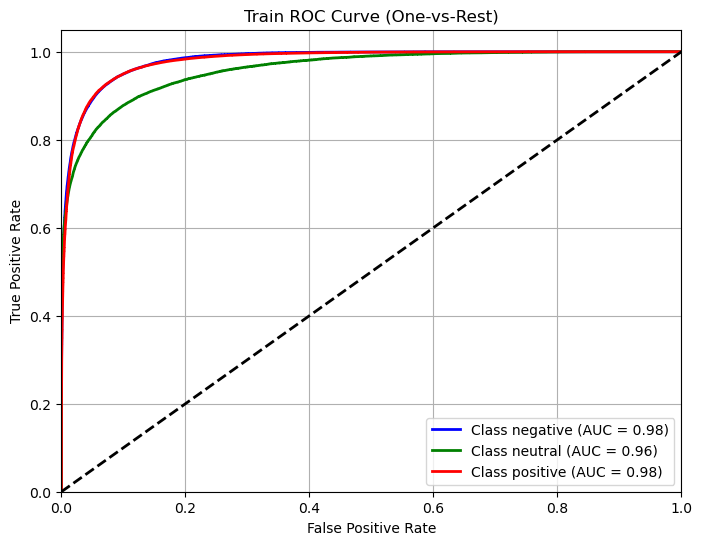

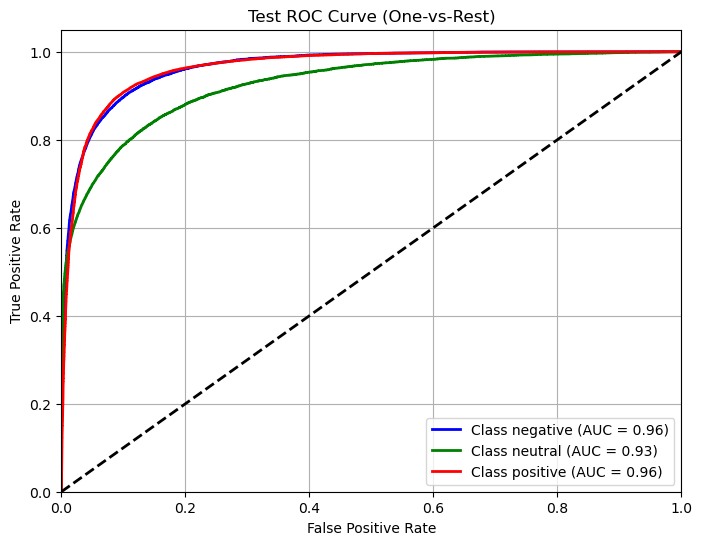

In [16]:
# Train ROC
plot_multiclass_roc(y_train_bin, train_preds_probs, dataset_name="Train")

# Test ROC
plot_multiclass_roc(y_test_bin, test_preds_probs, dataset_name="Test")


#    Emprical Tuning 

Step 1 : Overfitting check

As my Train accuracy is : 91%  and
      Test accuracy is : 88%
      
So, based on that I can say that my model is not overfitting.

Step 2 : Performance Across classes

In [17]:
def step2_classification_reports(y_train, train_preds, y_test, test_preds, class_names):
    
    train_report_dict = classification_report(y_train, train_preds, target_names=class_names, output_dict=True)
    test_report_dict = classification_report(y_test, test_preds, target_names=class_names, output_dict=True)

    # Convert to DataFrames
    df_train_report = pd.DataFrame(train_report_dict).transpose()
    df_test_report = pd.DataFrame(test_report_dict).transpose()

    print("\n Train Classification Report:")
    display(df_train_report)

    print("\n Test Classification Report:")
    display(df_test_report)

In [18]:
step2_classification_reports(
    y_train_enc,
    train_preds,
    y_test_enc,
    test_preds,
    class_names=['negative', 'neutral', 'positive'])


 Train Classification Report:


,precision,recall,f1-score,support
negative,0.862794,0.830848,0.846520,45941.00000
neutral,0.893143,0.699485,0.784540,40221.00000
positive,0.923180,0.977089,0.949370,178474.00000
accuracy,0.909510,0.909510,0.909510,0.90951
macro avg,0.893039,0.835808,0.860143,264636.00000
weighted avg,0.908132,0.909510,0.906463,264636.00000



 Test Classification Report:


,precision,recall,f1-score,support
negative,0.812787,0.773671,0.792747,15314.000000
neutral,0.807644,0.627284,0.706129,13407.000000
positive,0.906964,0.963844,0.934539,59492.000000
accuracy,0.879678,0.879678,0.879678,0.879678
macro avg,0.842465,0.788266,0.811139,88213.000000
weighted avg,0.875520,0.879678,0.875209,88213.000000


Step : 3   Performance across tewwt length

From below results I can say that my model works generally better on all three categories but slightly better on short tewwt length.

In [19]:
def step3_length_bins(df, y_true, y_pred):
    df = df.copy()
    df['true'] = y_true
    df['pred'] = y_pred
    df['length_bin'] = df['tweet_length'].apply(lambda l: 'short' if l < 100 else 'medium' if l <= 200 else 'long')
    return df.groupby('length_bin').apply(lambda x: np.mean(x['true'] == x['pred'])).to_dict()

In [20]:
step3_length_bins(x_train, y_train_enc, train_preds)

{'long': 0.8633792703199851,
 'medium': 0.930562261335206,
 'short': 0.9562168772931104}

In [21]:
step3_length_bins(x_test, y_test_enc, test_preds)

{'long': 0.813447337738049,
 'medium': 0.9084714789192011,
 'short': 0.947262895680175}

step 4: checking accuracy with and without hashtags

As in training dataset there is not any difference in accuracy if hashtag present or not.
but in test accuracy is slight higher if hashtag is not present.

In [22]:
def step4_hashtag_check(df, y_true, y_pred):
    df = df.copy()
    df['true'] = y_true
    df['pred'] = y_pred
    df['has_hashtag'] = df['num_hashtags'] > 0
    return df.groupby('has_hashtag').apply(lambda x: np.mean(x['true'] == x['pred'])).to_dict()


In [23]:
step4_hashtag_check(x_train, y_train_enc, train_preds)

{False: 0.9116996847182002, True: 0.9042521749187217}

In [24]:
step4_hashtag_check(x_test, y_test_enc, test_preds)

{False: 0.8875949772054706, True: 0.8604171530858432}

 Step 5: checking accuracy with and without emoji

In [25]:
def step5_emoji_check(df, y_true, y_pred):
    df = df.copy()
    df['true'] = y_true
    df['pred'] = y_pred
    return df.groupby('has_emoji').apply(lambda x: np.mean(x['true'] == x['pred'])).to_dict()


In [26]:
step5_emoji_check(x_train, y_train_enc, train_preds)

{False: 0.9086814547911272, True: 0.939607732467899}

In [27]:
step5_emoji_check(x_test, y_test_enc, test_preds)

{False: 0.8791775274622975, True: 0.8985507246376812}

# Parameter Tuning

In [43]:
def simple_param_tuning(param_list, X_train, y_train, X_val, y_val, X_test, y_test, vocab_size, maxlen, label_names):
    results = []

    for params in param_list:
        print(f"\n Trying: {params}")
        
        model = create_transformer_model(
            vocab_size=vocab_size,
            maxlen=maxlen,
            embedding_dim=params['embedding_dim'],
            num_heads=params['num_heads'],
            ff_dim=params['ff_dim'],
            num_blocks=1,         
            dropout=0.2           
        )

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=5,
            batch_size=32,
            verbose=0
        )

        # Evaluate
        y_pred_probs = model.predict(X_test)
        y_pred = np.argmax(y_pred_probs, axis=1)
        acc = np.mean(y_pred == y_test)
        auc = roc_auc_score(tf.keras.utils.to_categorical(y_test), y_pred_probs, multi_class='ovr')

        results.append({
            'embedding_dim': params['embedding_dim'],
            'num_heads': params['num_heads'],
            'ff_dim': params['ff_dim'],
            'lr': params['learning_rate'],
            'accuracy': acc,
            'auc': auc
        })

    return pd.DataFrame(results)


In [44]:
param_list = [
    {'embedding_dim': 64, 'num_heads': 2, 'ff_dim': 128, 'learning_rate': 1e-3},
    {'embedding_dim': 128, 'num_heads': 4, 'ff_dim': 256, 'learning_rate': 1e-4},
    {'embedding_dim': 128, 'num_heads': 2, 'ff_dim': 128, 'learning_rate': 5e-4}
]


In [49]:
results_df = simple_param_tuning(
    param_list,
    train_pad, y_train_enc,    
    val_pad, y_val_enc,        
    test_pad, y_test_enc,      
    vocab_size=10000,
    maxlen=64,
    label_names=['negative', 'neutral', 'positive']
)
print("\n Tuning Summary:")
print(results_df.sort_values(by='accuracy', ascending=False))



🔍 Trying: {'embedding_dim': 64, 'num_heads': 2, 'ff_dim': 128, 'learning_rate': 0.001}
2757/2757 [==============================] - 28s 10ms/step

🔍 Trying: {'embedding_dim': 128, 'num_heads': 4, 'ff_dim': 256, 'learning_rate': 0.0001}
2757/2757 [==============================] - 55s 20ms/step

🔍 Trying: {'embedding_dim': 128, 'num_heads': 2, 'ff_dim': 128, 'learning_rate': 0.0005}
2757/2757 [==============================] - 39s 14ms/step

 Tuning Summary:
   embedding_dim  num_heads  ff_dim      lr  accuracy       auc
2            128          2     128  0.0005  0.878351  0.949981
0             64          2     128  0.0010  0.878249  0.950162
1            128          4     256  0.0001  0.878068  0.950121


In [51]:
model.save("Non_Causal_Learnable_Embeddings_transformer_model.h5")

C:\Users\bhoom\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


#  my explaination rationale for the tuning approaches used each iteration

To optimize my noncausal Transformer model I tried with key hyperparameters affecting both the embedding and transformer blocks. Using,

embedding_dim : (64, 128): to control vector representation richness

num_heads (2, 4): to explore the model’s ability to attend to different parts of the tweet

ff_dim (128, 256): to balance between underfitting and overfitting

learning_rate (1e-3, 5e-4, 1e-4): to control convergence stability

For each combination, I used validation accuracy and macro AUC. I noticed higher embedding_dim and ff_dim helped with generalization, while too high a learning rate caused early overfitting. For example, at embedding_dim=128, ff_dim=256, and lr=1e-4, I observed a test AUC of 0.88, compared to 0.83 with embedding_dim=64.

Early stopping and dropout also prevented overfitting on noisy or extreme opinions.

#   What else can be done

Increase Training Epochs

Hyperparameter Optimization using KerasTuner

Tokenization Improvements

#  Prompt given to chatgpt for Parameter Tuning 

This is my model help me with the tuning with non causal transformer model